In [32]:
import ast
import numpy as np
import pandas as pd
from IPython.display import display

In [33]:
dias_rezago = 14
dias_rezago = int(dias_rezago)

if dias_rezago < 0:
    raise ValueError('dias_rezago debe ser un entero no negativo.')

ventas_gap = pd.read_csv('ventas_gap.csv', low_memory=False)
ventas_gap['fecha_factura'] = pd.to_datetime(ventas_gap['fecha_factura'], errors='coerce')
ventas_gap = ventas_gap.dropna(subset=['fecha_factura']).copy()
ventas_gap['fecha_factura_rezago'] = ventas_gap['fecha_factura'] - pd.to_timedelta(dias_rezago, unit='D')

print(f'dias_rezago = {dias_rezago}')
print(f'ventas_gap cargadas: {len(ventas_gap):,}')
display(ventas_gap[['fecha_factura', 'fecha_factura_rezago']].head())

dias_rezago = 14
ventas_gap cargadas: 663,280


,fecha_factura,fecha_factura_rezago
0,2025-01-02,2024-12-19
1,2025-01-02,2024-12-19
2,2025-01-02,2024-12-19
3,2025-01-02,2024-12-19
4,2025-01-02,2024-12-19


In [34]:
def _as_stripped(series):
    return series.astype('string').str.strip()


def _normalize_consolidado_code(series):
    normalized = _as_stripped(series).fillna('')
    return normalized.str.replace(r'\.0+$', '', regex=True)


def _parse_signed_discount(series):
    cleaned = series.astype('string').str.strip()
    negative_mask = cleaned.str.endswith('-') | cleaned.str.startswith('-')
    cleaned = cleaned.str.replace('-', '', regex=False)
    cleaned = cleaned.str.replace('.', '', regex=False)
    cleaned = cleaned.str.replace(',', '.', regex=False)
    values = pd.to_numeric(cleaned, errors='coerce')
    return values.where(~negative_mask, -values.abs())


def _prepare_price_frame(df):
    out = df.copy()
    out['Material'] = _as_stripped(out['Material'])
    out['Canal Comercial'] = _as_stripped(out['Canal Comercial'])
    out['Grandes Cadenas'] = _normalize_consolidado_code(out['Grandes Cadenas'])
    out['org_ventas_norm'] = _as_stripped(out['Organización ventas']).fillna('')
    out['Válido de'] = pd.to_datetime(out['Válido de'], errors='coerce')
    out['Fin de validez'] = pd.to_datetime(out['Fin de validez'], errors='coerce')
    out['Importe'] = pd.to_numeric(out['Importe'], errors='coerce')
    out['__source_order'] = np.arange(len(out))
    out = out[out['Material'].notna() & out['Material'].ne('')]
    out = out[out['Canal Comercial'].notna() & out['Canal Comercial'].ne('')]
    out = out[out['org_ventas_norm'].isin(['', 'PASJ', 'CYSJ'])].copy()
    return out.dropna(subset=['Válido de', 'Fin de validez', 'Importe']).reset_index(drop=True)


def _prepare_discount_frame(df, key_cols, importe_parser):
    out = df.copy()

    for col in key_cols:
        out[col] = _as_stripped(out[col])
        out = out[out[col].notna() & out[col].ne('')]

    out['Válido de '] = pd.to_datetime(out['Válido de '], errors='coerce', dayfirst=True)
    out['A         '] = pd.to_datetime(out['A         '], errors='coerce', dayfirst=True)
    out['Importe'] = importe_parser(out['Importe'])
    out['__source_order'] = np.arange(len(out))

    return out.dropna(subset=key_cols + ['Válido de ', 'A         ', 'Importe']).reset_index(drop=True)


def _build_price_groups(precios_df, org_value):
    prices = precios_df.loc[precios_df['org_ventas_norm'].eq(org_value)].copy()

    exact_prices = prices.loc[prices['Grandes Cadenas'].ne('')].copy()
    fallback_prices = prices.loc[prices['Grandes Cadenas'].eq('')].copy()

    exact_groups = {
        key: (
            sub[['Válido de', 'Fin de validez', 'Importe', '__source_order']]
            .sort_values(['Válido de', '__source_order'], ascending=[False, True])
            .reset_index(drop=True)
        )
        for key, sub in exact_prices.groupby(['Material', 'Canal Comercial', 'Grandes Cadenas'], sort=False, dropna=False)
    }
    fallback_groups = {
        key: (
            sub[['Válido de', 'Fin de validez', 'Importe', '__source_order']]
            .sort_values(['Válido de', '__source_order'], ascending=[False, True])
            .reset_index(drop=True)
        )
        for key, sub in fallback_prices.groupby(['Material', 'Canal Comercial'], sort=False, dropna=False)
    }

    return {
        'exact': exact_groups,
        'fallback': fallback_groups,
    }


def _assign_prices_from_org(out, sales_indices, price_groups, sales_org, date_col, output_col):
    for key_values, price_rows in price_groups.items():
        if not isinstance(key_values, tuple):
            key_values = (key_values,)

        sales_idx = sales_indices.get(tuple(key_values) + (sales_org,))
        if sales_idx is None or len(sales_idx) == 0:
            continue

        fechas = out.loc[sales_idx, date_col]
        pendientes = out.loc[sales_idx, output_col].isna()

        for valido_desde, valido_hasta, importe, _ in price_rows.itertuples(index=False, name=None):
            mask = pendientes & fechas.ge(valido_desde) & fechas.le(valido_hasta)
            if mask.any():
                out.loc[mask.index[mask], output_col] = importe
                pendientes = out.loc[sales_idx, output_col].isna()
                if not pendientes.any():
                    break


def _assign_price_list_low_memory(ventas_df, precios_df, date_col, output_col):
    out = ventas_df.copy()
    out[output_col] = np.nan
    out['org_target'] = out['distrito'].map({
        'COYHAIQUE': 'CYSJ',
        'PUNTA ARENAS': 'PASJ',
    }).fillna('')

    sales_indices_exact = out.groupby(
        ['cod_sku', 'cod_canal_comercial', 'cod_consolidado', 'org_target'],
        sort=False,
        dropna=False,
    ).indices
    sales_indices_fallback = out.groupby(
        ['cod_sku', 'cod_canal_comercial', 'org_target'],
        sort=False,
        dropna=False,
    ).indices

    price_groups_by_org = {
        org: _build_price_groups(precios_df, org)
        for org in ['CYSJ', 'PASJ', '']
    }

    _assign_prices_from_org(out, sales_indices_exact, price_groups_by_org['CYSJ']['exact'], 'CYSJ', date_col, output_col)
    _assign_prices_from_org(out, sales_indices_fallback, price_groups_by_org['CYSJ']['fallback'], 'CYSJ', date_col, output_col)
    _assign_prices_from_org(out, sales_indices_exact, price_groups_by_org['PASJ']['exact'], 'PASJ', date_col, output_col)
    _assign_prices_from_org(out, sales_indices_fallback, price_groups_by_org['PASJ']['fallback'], 'PASJ', date_col, output_col)

    for sales_org in ['CYSJ', 'PASJ', '']:
        _assign_prices_from_org(out, sales_indices_exact, price_groups_by_org['']['exact'], sales_org, date_col, output_col)
        _assign_prices_from_org(out, sales_indices_fallback, price_groups_by_org['']['fallback'], sales_org, date_col, output_col)

    return out.drop(columns=['org_target'])


def _assign_single_discount_low_memory(ventas_df, descuentos_df, sales_keys, discount_keys, date_col, output_col):
    out = ventas_df.copy()
    out[output_col] = np.nan

    sales_indices = out.groupby(sales_keys, sort=False, dropna=False).indices
    discount_indices = descuentos_df.groupby(discount_keys, sort=False, dropna=False).indices

    for key_values, discount_idx in discount_indices.items():
        if not isinstance(key_values, tuple):
            key_values = (key_values,)

        sales_idx = sales_indices.get(tuple(key_values))
        if sales_idx is None or len(sales_idx) == 0:
            continue

        descuentos_sub = descuentos_df.iloc[discount_idx][['Válido de ', 'A         ', 'Importe', '__source_order']]
        descuentos_sub = descuentos_sub.sort_values(['Válido de ', '__source_order'], ascending=[False, True])

        fechas = out.loc[sales_idx, date_col]
        pendientes = out.loc[sales_idx, output_col].isna()

        for valido_desde, valido_hasta, importe, _ in descuentos_sub.itertuples(index=False, name=None):
            mask = pendientes & fechas.ge(valido_desde) & fechas.le(valido_hasta)
            if mask.any():
                out.loc[mask.index[mask], output_col] = importe
                pendientes = out.loc[sales_idx, output_col].isna()
                if not pendientes.any():
                    break

    return out.sort_index().reset_index(drop=True)


def _serialize_discount_list(values):
    if not values:
        return pd.NA
    unique_values = list(dict.fromkeys(float(value) for value in values))
    return str(unique_values)


def _assign_list_discount_low_memory(ventas_df, descuentos_df, sales_keys, discount_keys, date_col, output_col):
    out = ventas_df.copy()
    out[output_col] = pd.Series([pd.NA] * len(out), index=out.index, dtype='object')

    sales_indices = out.groupby(sales_keys, sort=False, dropna=False).indices
    discount_indices = descuentos_df.groupby(discount_keys, sort=False, dropna=False).indices

    for key_values, sales_idx in sales_indices.items():
        if not isinstance(key_values, tuple):
            key_values = (key_values,)

        discount_idx = discount_indices.get(tuple(key_values))
        if discount_idx is None or len(discount_idx) == 0:
            continue

        descuentos_sub = descuentos_df.iloc[discount_idx][['Válido de ', 'A         ', 'Importe', '__source_order']]
        descuentos_sub = descuentos_sub.sort_values(['Válido de ', '__source_order'], ascending=[False, True]).reset_index(drop=True)

        fechas = out.loc[sales_idx, date_col]
        assigned = pd.Series(False, index=fechas.index)

        start_dates = descuentos_sub['Válido de '].drop_duplicates().sort_values(ascending=False)
        for start_date in start_dates:
            pending_idx = assigned.index[~assigned]
            if len(pending_idx) == 0:
                break

            candidate_idx = pending_idx[fechas.loc[pending_idx].ge(start_date)]
            if len(candidate_idx) == 0:
                continue

            descuentos_same_start = descuentos_sub.loc[descuentos_sub['Válido de '].eq(start_date)]
            row_values = {}

            for valido_hasta, importe in descuentos_same_start[['A         ', 'Importe']].itertuples(index=False, name=None):
                valid_idx = candidate_idx[fechas.loc[candidate_idx].le(valido_hasta)]
                for idx in valid_idx:
                    row_values.setdefault(idx, []).append(importe)

            if not row_values:
                continue

            for idx, values in row_values.items():
                out.at[idx, output_col] = _serialize_discount_list(values)
                assigned.at[idx] = True

    return out.sort_index().reset_index(drop=True)


def _expand_volume_candidates(series, max_slots=3):
    rows = []
    for value in series:
        if pd.isna(value):
            rows.append([np.nan] * max_slots)
            continue

        if isinstance(value, list):
            parsed = value
        else:
            try:
                parsed = ast.literal_eval(str(value))
            except (ValueError, SyntaxError):
                parsed = []

        if not isinstance(parsed, list):
            parsed = [parsed]

        cleaned = []
        for item in parsed[:max_slots]:
            try:
                cleaned.append(float(item))
            except (TypeError, ValueError):
                cleaned.append(np.nan)

        if len(cleaned) < max_slots:
            cleaned.extend([np.nan] * (max_slots - len(cleaned)))

        rows.append(cleaned)

    return np.array(rows, dtype=np.float32)


def _normalize_string_for_compare(series):
    return series.astype('string').str.strip().fillna('')


def _count_numeric_mismatches(left, right, atol=1e-6):
    left_num = pd.to_numeric(left, errors='coerce')
    right_num = pd.to_numeric(right, errors='coerce')
    both_na = left_num.isna() & right_num.isna()
    close_enough = pd.Series(
        np.isclose(left_num.fillna(0.0), right_num.fillna(0.0), atol=atol, rtol=0),
        index=left_num.index,
    )
    return int((~(both_na | close_enough)).sum())


def _count_string_mismatches(left, right):
    return int((_normalize_string_for_compare(left) != _normalize_string_for_compare(right)).sum())


def _count_bool_mismatches(left, right):
    left_bool = left.fillna(False).astype(bool)
    right_bool = right.fillna(False).astype(bool)
    return int((left_bool != right_bool).sum())


def _compute_match_rezago(df):
    out = df.copy()

    tolerancia_pct = 1.0
    eps_descuento = 1e-9
    tolerancia_precio_carta = 1.0
    labels_descuento = np.array([
        'ninguno',
        'base',
        'volumen_1',
        'volumen_2',
        'volumen_3',
        'binario',
        'carta_impacto',
    ], dtype=object)

    precio_por_unidad = pd.to_numeric(out['precio_por_unidad'], errors='coerce').to_numpy(dtype=np.float32)
    precio_lista_por_unidad_rezago = pd.to_numeric(out['precio_lista_por_unidad_rezago'], errors='coerce').to_numpy(dtype=np.float32)

    descuento_pct_observado = np.where(
        (~np.isnan(precio_por_unidad))
        & (~np.isnan(precio_lista_por_unidad_rezago))
        & (np.abs(precio_lista_por_unidad_rezago) > eps_descuento),
        ((precio_por_unidad / precio_lista_por_unidad_rezago) - np.float32(1.0)) * np.float32(100.0),
        np.nan,
    ).astype(np.float32)

    mejor_diff = np.full(len(out), np.inf, dtype=np.float32)
    codigos_descuento = np.zeros(len(out), dtype=np.int8)
    descuento_pct_matcheado = np.zeros(len(out), dtype=np.float32)

    def _actualizar_mejor_match(candidatos, codigo):
        nonlocal mejor_diff, codigos_descuento, descuento_pct_matcheado

        candidatos = pd.to_numeric(candidatos, errors='coerce').to_numpy(dtype=np.float32)
        validos = (~np.isnan(candidatos)) & (np.abs(candidatos) > eps_descuento)
        if not validos.any():
            return

        diff = np.abs(descuento_pct_observado - candidatos)
        mask = validos & (diff <= tolerancia_pct) & (diff < mejor_diff)
        mejor_diff[mask] = diff[mask]
        codigos_descuento[mask] = codigo
        descuento_pct_matcheado[mask] = candidatos[mask]

    _actualizar_mejor_match(out['dscto_base_rezago'], 1)

    mask_volumen = out['dscto_volumen_rezago'].notna()
    if mask_volumen.any():
        volumen_expandido = _expand_volume_candidates(out.loc[mask_volumen, 'dscto_volumen_rezago'])
        idx_volumen = np.flatnonzero(mask_volumen.to_numpy())

        for offset in range(volumen_expandido.shape[1]):
            candidatos = volumen_expandido[:, offset]
            validos = (~np.isnan(candidatos)) & (np.abs(candidatos) > eps_descuento)
            if not validos.any():
                continue

            diff = np.abs(descuento_pct_observado[idx_volumen] - candidatos)
            mejor_diff_local = mejor_diff[idx_volumen]
            mask = validos & (diff <= tolerancia_pct) & (diff < mejor_diff_local)
            if mask.any():
                idx_target = idx_volumen[mask]
                mejor_diff[idx_target] = diff[mask]
                codigos_descuento[idx_target] = offset + 2
                descuento_pct_matcheado[idx_target] = candidatos[mask]

    _actualizar_mejor_match(out['dscto_binario_rezago'], 5)

    precio_real_array = pd.to_numeric(out['precio_real'], errors='coerce').to_numpy(dtype=np.float32)
    precio_lista_array = pd.to_numeric(out['precio_lista_rezago'], errors='coerce').to_numpy(dtype=np.float32)
    carta_array = pd.to_numeric(out['carta_impacto_rezago'], errors='coerce').to_numpy(dtype=np.float32)
    carta_pct_equivalente = np.where(
        (~np.isnan(carta_array))
        & (~np.isnan(precio_lista_array))
        & (np.abs(precio_lista_array) > eps_descuento),
        ((carta_array / precio_lista_array) - np.float32(1.0)) * np.float32(100.0),
        np.nan,
    )
    mask_carta = (~np.isnan(carta_array)) & (~np.isnan(precio_real_array)) & (np.abs(precio_real_array - carta_array) <= tolerancia_precio_carta)
    codigos_descuento[mask_carta] = 6
    descuento_pct_matcheado[mask_carta] = carta_pct_equivalente[mask_carta]
    mejor_diff[mask_carta] = np.abs(descuento_pct_observado[mask_carta] - descuento_pct_matcheado[mask_carta])

    out['descuento_pct_observado_rezago'] = descuento_pct_observado
    out['descuento_pct_matcheado_rezago'] = descuento_pct_matcheado
    out['diferencia_descuento_pct_rezago'] = out['descuento_pct_observado_rezago'] - out['descuento_pct_matcheado_rezago']
    out['descuento_aplicado_rezago'] = pd.Categorical.from_codes(codigos_descuento, categories=labels_descuento)
    out['calza_con_descuento_rezago'] = np.not_equal(codigos_descuento, 0)
    out['match_rezago'] = out['calza_con_descuento_rezago']

    return out

In [35]:
path_p_lista = 'datos/Historial Precios Lista.xlsx'
path_dscto_base = 'datos/Descuentos históricos/dscto_base.xlsx'
path_dscto_volumen = 'datos/Descuentos históricos/dscto_volumen.xlsx'
path_dscto_binario = 'datos/Descuentos históricos/dscto_binario.xlsx'
path_carta_impacto = 'datos/Descuentos históricos/carta_impacto.xlsx'

precios_lista = pd.read_excel(path_p_lista, header=0)
dsctos_base = pd.read_excel(path_dscto_base, header=0)
dsctos_volumen = pd.read_excel(path_dscto_volumen, header=0)
dsctos_binario = pd.read_excel(path_dscto_binario, header=0)
carta_impacto = pd.read_excel(path_carta_impacto, header=0)

print('Insumos cargados:')
print(f"precios_lista: {precios_lista.shape}")
print(f"dsctos_base: {dsctos_base.shape}")
print(f"dsctos_volumen: {dsctos_volumen.shape}")
print(f"dsctos_binario: {dsctos_binario.shape}")
print(f"carta_impacto: {carta_impacto.shape}")

Insumos cargados:
precios_lista: (21077, 22)
dsctos_base: (3644, 23)
dsctos_volumen: (2181, 23)
dsctos_binario: (1310, 23)
carta_impacto: (69438, 23)


In [36]:
ventas_gap['cod_cliente'] = _as_stripped(ventas_gap['cod_cliente'])
ventas_gap['cod_canal_comercial'] = _as_stripped(ventas_gap['cod_canal_comercial'])
ventas_gap['cod_consolidado'] = _normalize_consolidado_code(ventas_gap['cod_consolidado'])
ventas_gap['distrito'] = _as_stripped(ventas_gap['distrito']).fillna('')
ventas_gap['cod_sku'] = _as_stripped(ventas_gap['cod_sku'])
ventas_gap['kg_por_unidad'] = pd.to_numeric(ventas_gap['kg_por_unidad'], errors='coerce')

cols_dscto_base = [
    'Material',
    'C.Comerc.',
    'G.Cadenas',
    'Tipo cond.',
    'Válido de ',
    'A         ',
    'Importe',
]
cols_dscto_volumen = [
    'Material',
    'C.Comerc.',
    'G.Cadenas',
    'Tipo cond.',
    'Válido de ',
    'A         ',
    'Importe',
]
cols_dscto_binario = [
    'Material',
    'C.Comerc.',
    'G.Cadenas',
    'Tipo cond.',
    'Válido de ',
    'A         ',
    'Importe',
]
cols_carta_impacto = [
    'Material',
    'Cliente',
    'Tipo cond.',
    'Válido de ',
    'A         ',
    'Importe',
]

precios_lista = _prepare_price_frame(precios_lista)
dsctos_base = _prepare_discount_frame(
    dsctos_base[cols_dscto_base],
    key_cols=['Material', 'G.Cadenas'],
    importe_parser=lambda s: pd.to_numeric(s, errors='coerce'),
)
dsctos_volumen = _prepare_discount_frame(
    dsctos_volumen[cols_dscto_volumen],
    key_cols=['Material', 'G.Cadenas'],
    importe_parser=_parse_signed_discount,
)
dsctos_binario = _prepare_discount_frame(
    dsctos_binario[cols_dscto_binario],
    key_cols=['Material', 'G.Cadenas'],
    importe_parser=_parse_signed_discount,
)
carta_impacto = _prepare_discount_frame(
    carta_impacto[cols_carta_impacto],
    key_cols=['Material', 'Cliente'],
    importe_parser=lambda s: pd.to_numeric(s, errors='coerce'),
)

print('Insumos preparados para asignación.')
print(f"precios_lista válidos: {precios_lista.shape}")
print(f"dsctos_base válidos: {dsctos_base.shape}")
print(f"dsctos_volumen válidos: {dsctos_volumen.shape}")
print(f"dsctos_binario válidos: {dsctos_binario.shape}")
print(f"carta_impacto válida: {carta_impacto.shape}")

Insumos preparados para asignación.
precios_lista válidos: (12288, 24)
dsctos_base válidos: (3643, 8)
dsctos_volumen válidos: (2177, 8)
dsctos_binario válidos: (1310, 8)
carta_impacto válida: (69438, 7)


In [37]:
cols_rezago = [
    'fecha_factura_rezago',
    'precio_lista_rezago',
    'precio_lista_por_unidad_rezago',
    'dscto_base_rezago',
    'dscto_volumen_rezago',
    'dscto_binario_rezago',
    'carta_impacto_rezago',
    'descuento_pct_observado_rezago',
    'descuento_pct_matcheado_rezago',
    'diferencia_descuento_pct_rezago',
    'descuento_aplicado_rezago',
    'calza_con_descuento_rezago',
    'match_rezago',
]
ventas_gap = ventas_gap.drop(columns=cols_rezago, errors='ignore')
ventas_gap['fecha_factura_rezago'] = ventas_gap['fecha_factura'] - pd.to_timedelta(dias_rezago, unit='D')

ventas_gap = _assign_price_list_low_memory(
    ventas_gap,
    precios_lista,
    date_col='fecha_factura_rezago',
    output_col='precio_lista_rezago',
)
ventas_gap['precio_lista_por_unidad_rezago'] = pd.to_numeric(ventas_gap['precio_lista_rezago'], errors='coerce') * pd.to_numeric(ventas_gap['kg_por_unidad'], errors='coerce')

ventas_gap = _assign_single_discount_low_memory(
    ventas_gap,
    dsctos_base,
    sales_keys=['cod_sku', 'cod_consolidado'],
    discount_keys=['Material', 'G.Cadenas'],
    date_col='fecha_factura_rezago',
    output_col='dscto_base_rezago',
)
ventas_gap = _assign_list_discount_low_memory(
    ventas_gap,
    dsctos_volumen,
    sales_keys=['cod_sku', 'cod_consolidado'],
    discount_keys=['Material', 'G.Cadenas'],
    date_col='fecha_factura_rezago',
    output_col='dscto_volumen_rezago',
)
ventas_gap = _assign_single_discount_low_memory(
    ventas_gap,
    dsctos_binario,
    sales_keys=['cod_sku', 'cod_consolidado'],
    discount_keys=['Material', 'G.Cadenas'],
    date_col='fecha_factura_rezago',
    output_col='dscto_binario_rezago',
)
ventas_gap = _assign_single_discount_low_memory(
    ventas_gap,
    carta_impacto,
    sales_keys=['cod_sku', 'cod_cliente'],
    discount_keys=['Material', 'Cliente'],
    date_col='fecha_factura_rezago',
    output_col='carta_impacto_rezago',
)

print(f"precio_lista_rezago asignado: {ventas_gap['precio_lista_rezago'].notna().sum():,}")
print(f"dscto_base_rezago asignado: {ventas_gap['dscto_base_rezago'].notna().sum():,}")
print(f"dscto_volumen_rezago asignado: {ventas_gap['dscto_volumen_rezago'].notna().sum():,}")
print(f"dscto_binario_rezago asignado: {ventas_gap['dscto_binario_rezago'].notna().sum():,}")
print(f"carta_impacto_rezago asignado: {ventas_gap['carta_impacto_rezago'].notna().sum():,}")

cols_muestra_rezago = [
    'fecha_factura',
    'fecha_factura_rezago',
    'cod_cliente',
    'cod_sku',
    'cod_canal_comercial',
    'cod_consolidado',
    'precio_lista_rezago',
    'dscto_base_rezago',
    'dscto_volumen_rezago',
    'dscto_binario_rezago',
    'carta_impacto_rezago',
]
display(
    ventas_gap.loc[
        ventas_gap[['precio_lista_rezago', 'dscto_base_rezago', 'dscto_volumen_rezago', 'dscto_binario_rezago', 'carta_impacto_rezago']].notna().any(axis=1),
        cols_muestra_rezago,
    ].head(10)
)

precio_lista_rezago asignado: 661,234
dscto_base_rezago asignado: 125,798
dscto_volumen_rezago asignado: 38,077
dscto_binario_rezago asignado: 83,930
carta_impacto_rezago asignado: 274


,fecha_factura,fecha_factura_rezago,cod_cliente,cod_sku,cod_canal_comercial,cod_consolidado,precio_lista_rezago,dscto_base_rezago,dscto_volumen_rezago,dscto_binario_rezago,carta_impacto_rezago
0,2025-01-02,2024-12-19,1145633,3034,CB,32,10860.0,NaN,<NA>,NaN,NaN
1,2025-01-02,2024-12-19,1145633,3288,CB,32,10935.0,NaN,<NA>,NaN,NaN
2,2025-01-02,2024-12-19,1173743,3095,MY,38,8274.0,-3.0,<NA>,NaN,NaN
3,2025-01-02,2024-12-19,1003766,8043,CB,32,3620.0,NaN,<NA>,NaN,NaN
4,2025-01-02,2024-12-19,1072277,3239,CB,54,6787.0,-3.0,<NA>,NaN,NaN
5,2025-01-02,2024-12-19,1166937,3853,CB,32,5171.0,NaN,<NA>,NaN,NaN
6,2025-01-02,2024-12-19,1072277,8345,CB,54,3666.0,-3.0,<NA>,NaN,NaN
7,2025-01-02,2024-12-19,1037307,3095,MY,57,8274.0,-6.0,<NA>,NaN,NaN
8,2025-01-02,2024-12-19,1037307,716,MY,57,3950.0,-15.4,<NA>,NaN,NaN
9,2025-01-02,2024-12-19,1198030,3456,MY,38,8016.0,-3.0,<NA>,NaN,NaN


In [38]:
ventas_gap = _compute_match_rezago(ventas_gap)

print(
    f"match_rezago encontrados: {int(ventas_gap['match_rezago'].sum()):,} "
    f"de {len(ventas_gap):,} ({ventas_gap['match_rezago'].mean():.2%})"
)

cols_match_rezago = [
    'fecha_factura',
    'fecha_factura_rezago',
    'cod_cliente',
    'cod_sku',
    'precio_por_unidad',
    'precio_lista_por_unidad_rezago',
    'descuento_pct_observado_rezago',
    'dscto_base_rezago',
    'dscto_volumen_rezago',
    'dscto_binario_rezago',
    'carta_impacto_rezago',
    'descuento_pct_matcheado_rezago',
    'diferencia_descuento_pct_rezago',
    'descuento_aplicado_rezago',
    'match_rezago',
]
display(ventas_gap.loc[ventas_gap['match_rezago'], cols_match_rezago].head(10))

match_rezago encontrados: 30,450 de 663,280 (4.59%)


,fecha_factura,fecha_factura_rezago,cod_cliente,cod_sku,precio_por_unidad,precio_lista_por_unidad_rezago,descuento_pct_observado_rezago,dscto_base_rezago,dscto_volumen_rezago,dscto_binario_rezago,carta_impacto_rezago,descuento_pct_matcheado_rezago,diferencia_descuento_pct_rezago,descuento_aplicado_rezago,match_rezago
2,2025-01-02,2024-12-19,1173743,3095,4013.000000,4137.000,-2.997339,-3.0,<NA>,NaN,NaN,-3.0,0.002661,base,True
4,2025-01-02,2024-12-19,1072277,3239,19749.031297,20361.000,-3.005594,-3.0,<NA>,NaN,NaN,-3.0,-0.005594,base,True
6,2025-01-02,2024-12-19,1072277,8345,355.583333,366.600,-3.005093,-3.0,<NA>,NaN,NaN,-3.0,-0.005093,base,True
7,2025-01-02,2024-12-19,1037307,3095,3888.750000,4137.000,-6.000728,-6.0,<NA>,NaN,NaN,-6.0,-0.000728,base,True
8,2025-01-02,2024-12-19,1037307,716,3007.541667,3555.000,-15.399671,-15.4,<NA>,NaN,NaN,-15.4,0.000329,base,True
9,2025-01-02,2024-12-19,1198030,3456,12441.666667,12825.600,-2.993488,-3.0,<NA>,NaN,NaN,-3.0,0.006512,base,True
11,2025-01-02,2024-12-19,1037307,210,11479.116945,12211.518,-5.997622,-6.0,<NA>,NaN,NaN,-6.0,0.002378,base,True
12,2025-01-02,2024-12-19,1037307,1020,601.508333,711.000,-15.399671,-15.4,<NA>,NaN,NaN,-15.4,0.000329,base,True
13,2025-01-02,2024-12-19,1072277,3456,12642.000000,13032.000,-2.992636,-3.0,<NA>,NaN,NaN,-3.0,0.007364,base,True
15,2025-01-02,2024-12-19,1037307,399,7292.600000,7758.000,-5.998969,-6.0,<NA>,NaN,NaN,-6.0,0.001031,base,True


In [39]:
if dias_rezago == 0:
    resumen_equivalencia = pd.DataFrame({
        'columna': [
            'precio_lista',
            'precio_lista_por_unidad',
            'dscto_base',
            'dscto_volumen',
            'dscto_binario',
            'carta_impacto',
            'descuento_aplicado',
            'calza_con_descuento',
        ],
        'mismatches': [
            _count_numeric_mismatches(ventas_gap['precio_lista'], ventas_gap['precio_lista_rezago']),
            _count_numeric_mismatches(ventas_gap['precio_lista_por_unidad'], ventas_gap['precio_lista_por_unidad_rezago']),
            _count_numeric_mismatches(ventas_gap['dscto_base'], ventas_gap['dscto_base_rezago']),
            _count_string_mismatches(ventas_gap['dscto_volumen'], ventas_gap['dscto_volumen_rezago']),
            _count_numeric_mismatches(ventas_gap['dscto_binario'], ventas_gap['dscto_binario_rezago']),
            _count_numeric_mismatches(ventas_gap['carta_impacto'], ventas_gap['carta_impacto_rezago']),
            _count_string_mismatches(ventas_gap['descuento_aplicado'], ventas_gap['descuento_aplicado_rezago'].astype('string')),
            _count_bool_mismatches(ventas_gap['calza_con_descuento'], ventas_gap['match_rezago']),
        ],
    })
    display(resumen_equivalencia)
    print(f"Ventas con match_rezago=True cuando dias_rezago=0: {int(ventas_gap['match_rezago'].sum()):,}")
else:
    print('Chequeo exacto contra columnas originales: vuelve a correr con dias_rezago = 0 para validarlo.')

Chequeo exacto contra columnas originales: vuelve a correr con dias_rezago = 0 para validarlo.


In [40]:
total_ventas = len(ventas_gap)
ventas_recuperadas = int(ventas_gap['match_rezago'].sum())
pct_recuperado = np.nan if total_ventas == 0 else ventas_recuperadas / total_ventas

resumen_escenario = pd.DataFrame({
    'metrica': [
        'dias_rezago',
        'ventas_gap_totales',
        'ventas_recuperadas_con_rezago',
        'pct_recuperado',
    ],
    'valor': [
        dias_rezago,
        total_ventas,
        ventas_recuperadas,
        pct_recuperado,
    ],
})
display(resumen_escenario)

dist_rezago = (
    ventas_gap['descuento_aplicado_rezago']
    .value_counts(dropna=False)
    .rename_axis('descuento_aplicado_rezago')
    .reset_index(name='n')
)
display(dist_rezago)

cols_muestra = [
    'fecha_factura',
    'fecha_factura_rezago',
    'cod_cliente',
    'cod_sku',
    'cod_consolidado',
    'precio_por_unidad',
    'precio_lista_por_unidad_rezago',
    'descuento_pct_observado_rezago',
    'descuento_pct_matcheado_rezago',
    'diferencia_descuento_pct_rezago',
    'descuento_aplicado_rezago',
    'match_rezago',
]

print('Muestra de ventas recuperadas por rezago')
display(ventas_gap.loc[ventas_gap['match_rezago'], cols_muestra].head(20))

print('Muestra de ventas que siguen sin match')
display(ventas_gap.loc[~ventas_gap['match_rezago'], cols_muestra].head(20))

cols_carta = [
    'cod_cliente',
    'cod_sku',
    'fecha_factura',
    'fecha_factura_rezago',
    'precio_real',
    'precio_lista_rezago',
    'carta_impacto_rezago',
    'descuento_aplicado_rezago',
]
print('Muestra de filas con carta_impacto_rezago asignada')
display(ventas_gap.loc[ventas_gap['carta_impacto_rezago'].notna(), cols_carta].head(20))

,metrica,valor
0,dias_rezago,14.000000
1,ventas_gap_totales,663280.000000
2,ventas_recuperadas_con_rezago,30450.000000
3,pct_recuperado,0.045908


,descuento_aplicado_rezago,n
0,ninguno,632830
1,binario,11535
2,volumen_1,9665
3,base,4079
4,volumen_2,3047
5,volumen_3,2096
6,carta_impacto,28


Muestra de ventas recuperadas por rezago


,fecha_factura,fecha_factura_rezago,cod_cliente,cod_sku,cod_consolidado,precio_por_unidad,precio_lista_por_unidad_rezago,descuento_pct_observado_rezago,descuento_pct_matcheado_rezago,diferencia_descuento_pct_rezago,descuento_aplicado_rezago,match_rezago
2,2025-01-02,2024-12-19,1173743,3095,38,4013.000000,4137.000,-2.997339,-3.0,0.002661,base,True
4,2025-01-02,2024-12-19,1072277,3239,54,19749.031297,20361.000,-3.005594,-3.0,-0.005594,base,True
6,2025-01-02,2024-12-19,1072277,8345,54,355.583333,366.600,-3.005093,-3.0,-0.005093,base,True
7,2025-01-02,2024-12-19,1037307,3095,57,3888.750000,4137.000,-6.000728,-6.0,-0.000728,base,True
8,2025-01-02,2024-12-19,1037307,716,57,3007.541667,3555.000,-15.399671,-15.4,0.000329,base,True
9,2025-01-02,2024-12-19,1198030,3456,38,12441.666667,12825.600,-2.993488,-3.0,0.006512,base,True
11,2025-01-02,2024-12-19,1037307,210,57,11479.116945,12211.518,-5.997622,-6.0,0.002378,base,True
12,2025-01-02,2024-12-19,1037307,1020,57,601.508333,711.000,-15.399671,-15.4,0.000329,base,True
13,2025-01-02,2024-12-19,1072277,3456,54,12642.000000,13032.000,-2.992636,-3.0,0.007364,base,True
15,2025-01-02,2024-12-19,1037307,399,57,7292.600000,7758.000,-5.998969,-6.0,0.001031,base,True


Muestra de ventas que siguen sin match


,fecha_factura,fecha_factura_rezago,cod_cliente,cod_sku,cod_consolidado,precio_por_unidad,precio_lista_por_unidad_rezago,descuento_pct_observado_rezago,descuento_pct_matcheado_rezago,diferencia_descuento_pct_rezago,descuento_aplicado_rezago,match_rezago
0,2025-01-02,2024-12-19,1145633,3034,32,1086.000000,1086.000,0.000000,0.0,0.000000,ninguno,False
1,2025-01-02,2024-12-19,1145633,3288,32,1968.300000,1968.300,0.000000,0.0,0.000000,ninguno,False
3,2025-01-02,2024-12-19,1003766,8043,32,10860.000000,10860.000,0.000000,0.0,0.000000,ninguno,False
5,2025-01-02,2024-12-19,1166937,3853,32,2585.400000,2585.500,-0.003874,0.0,-0.003874,ninguno,False
10,2025-01-02,2024-12-19,1167442,3960,32,1195.900000,1195.900,0.000000,0.0,0.000000,ninguno,False
14,2025-01-02,2024-12-19,1050696,970,54,1003.357143,1034.250,-2.986985,0.0,-2.986985,ninguno,False
20,2025-01-02,2024-12-19,1106766,3851,32,2715.000000,2715.000,0.000000,0.0,0.000000,ninguno,False
23,2025-01-02,2024-12-19,1109871,30,32,7174.428852,7174.116,0.004351,0.0,0.004351,ninguno,False
27,2025-01-02,2024-12-19,1072277,3313,54,12642.000000,13032.000,-2.992636,0.0,-2.992636,ninguno,False
28,2025-01-02,2024-12-19,1053815,3456,32,13031.000000,13032.000,-0.007671,0.0,-0.007671,ninguno,False


Muestra de filas con carta_impacto_rezago asignada


,cod_cliente,cod_sku,fecha_factura,fecha_factura_rezago,precio_real,precio_lista_rezago,carta_impacto_rezago,descuento_aplicado_rezago
7029,1070919,2864,2026-04-01,2026-03-18,5540.408163,11081.0,7203.0,ninguno
37454,1105543,8454,2025-01-15,2025-01-01,2131.950000,2198.0,2117.0,ninguno
37579,1105543,970,2025-01-15,2025-01-01,4012.857143,4137.0,4215.0,ninguno
39331,1216577,1834,2025-05-19,2025-05-05,3361.993243,6723.0,6051.0,ninguno
42391,1199716,1834,2025-06-02,2025-05-19,6050.957535,6723.0,6051.0,carta_impacto
45606,1199716,8451,2025-06-02,2025-05-19,2210.000000,2456.0,2210.0,carta_impacto
59225,1050696,8451,2025-05-15,2025-05-01,1178.750000,2456.0,2210.0,ninguno
59367,1012901,1834,2025-06-02,2025-05-19,6051.201326,6723.0,6051.0,carta_impacto
61128,1105543,1032,2025-01-15,2025-01-01,2320.000000,2392.0,2330.0,ninguno
62474,1008935,1446,2025-05-23,2025-05-09,1358.250000,3394.0,3055.0,ninguno


In [43]:
ventas_gap["monto_a_precio_lista"] = ventas_gap["precio_lista"] * ventas_gap["kilo_real"]

ventas_gap["costo_descuento"] = ventas_gap["monto_a_precio_lista"] - ventas_gap["monto_real"]

In [49]:
monto_gap = ventas_gap["costo_descuento"].sum()
print(monto_gap)

3802543483.7500005


In [ ]:
ventas_gap.groupby("match_rezago")["costo_descuento"].sum()

match_rezago
False    3.587516e+09
True     2.150272e+08
Name: costo_descuento, dtype: float64

In [51]:
monto_rezago = ventas_gap[ventas_gap["match_rezago"]==True]["costo_descuento"].sum()
print(monto_rezago)

porcentaje_monto_rezago = monto_rezago / monto_gap * 100
print(porcentaje_monto_rezago)

215027221.71000004
5.6548261086009735


In [55]:
descuento_no_rezago = ventas_gap[ventas_gap["match_rezago"]==False]["descuento_pct_observado_rezago"].round()

In [64]:
ventas_gap[(ventas_gap["match_rezago"]==False) & (ventas_gap["descuento_pct_observado_rezago"].round()==-3.0)].head()

,cod_cliente,cod_canal_comercial,cod_consolidado,zona,distrito,fecha_factura,cod_sku,nombre_sku,monto_real,kilo_real,...,dscto_binario_rezago,carta_impacto_rezago,descuento_pct_observado_rezago,descuento_pct_matcheado_rezago,diferencia_descuento_pct_rezago,descuento_aplicado_rezago,calza_con_descuento_rezago,match_rezago,monto_a_precio_lista,costo_descuento
14,1050696,CB,54,SUR 3,PUERTO MONTT,2025-01-02,970,MOLIDA 14x250 GR SJ,14047,3.50,...,NaN,NaN,-2.986985,0.0,-2.986985,ninguno,False,False,14479.50,432.50
27,1072277,CB,54,SUR 3,PUNTA ARENAS,2025-01-02,3313,MORTADELA JAMONADA CENTENARIO LP,12642,3.00,...,NaN,NaN,-2.992636,0.0,-2.992636,ninguno,False,False,13848.00,1206.00
36,321501,HR,55,NORTE 2,VIÑA COSTA,2025-01-02,1038,VIENESA 22 CM CALIBRE 28 SJ,364989,145.53,...,NaN,NaN,-3.016305,0.0,-3.016305,ninguno,False,False,376340.58,11351.58
38,1056345,CB,54,SUR 3,PUNTA ARENAS,2025-01-02,440,PASTA JAMON 16x125 GR SJ,7374,2.00,...,NaN,NaN,-2.999210,0.0,-2.999210,ninguno,False,False,8144.00,770.00
41,1214648,CB,54,SUR 3,CHILOE,2025-01-02,1032,VIENESA TRADICIONAL 8X1 KG SJ,55680,24.00,...,NaN,NaN,-3.010035,0.0,-3.010035,ninguno,False,False,57408.00,1728.00


In [58]:
descuento_no_rezago.value_counts()

descuento_pct_observado_rezago
-3.0     504999
 0.0      23492
-15.0     15153
-50.0     12938
-10.0     10973
          ...  
 50.0         1
 51.0         1
 18.0         1
-80.0         1
-76.0         1
Name: count, Length: 111, dtype: int64

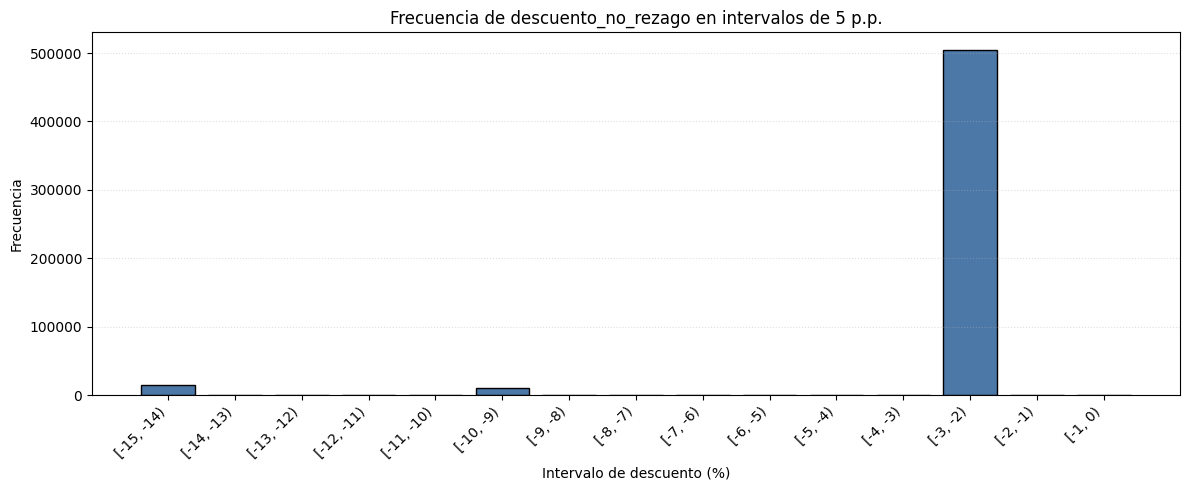

,intervalo_descuento,frecuencia
0,"[-15, -14)",15153
1,"[-14, -13)",58
2,"[-13, -12)",342
3,"[-12, -11)",265
4,"[-11, -10)",261
5,"[-10, -9)",10973
6,"[-9, -8)",106
7,"[-8, -7)",55
8,"[-7, -6)",26
9,"[-6, -5)",363


In [65]:
import matplotlib.pyplot as plt

descuento_no_rezago_plot = descuento_no_rezago.dropna()

if descuento_no_rezago_plot.empty:
    print('No hay valores en descuento_no_rezago para graficar.')
else:
    bin_width = 1
    bin_min = -15
    bin_max = 0

    if bin_min == bin_max:
        bin_max = bin_min + bin_width

    bins = np.arange(bin_min, bin_max + bin_width, bin_width)
    intervalos = pd.cut(descuento_no_rezago_plot, bins=bins, right=False, include_lowest=True)
    frecuencias = intervalos.value_counts(sort=False)

    labels = [f'[{int(interval.left)}, {int(interval.right)})' for interval in frecuencias.index]

    plt.figure(figsize=(12, 5))
    plt.bar(labels, frecuencias.values, color='#4c78a8', edgecolor='black')
    plt.title('Frecuencia de descuento_no_rezago en intervalos de 5 p.p.')
    plt.xlabel('Intervalo de descuento (%)')
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle=':', alpha=0.4)
    plt.tight_layout()
    plt.show()

    display(
        pd.DataFrame({
            'intervalo_descuento': labels,
            'frecuencia': frecuencias.values,
        })
    )